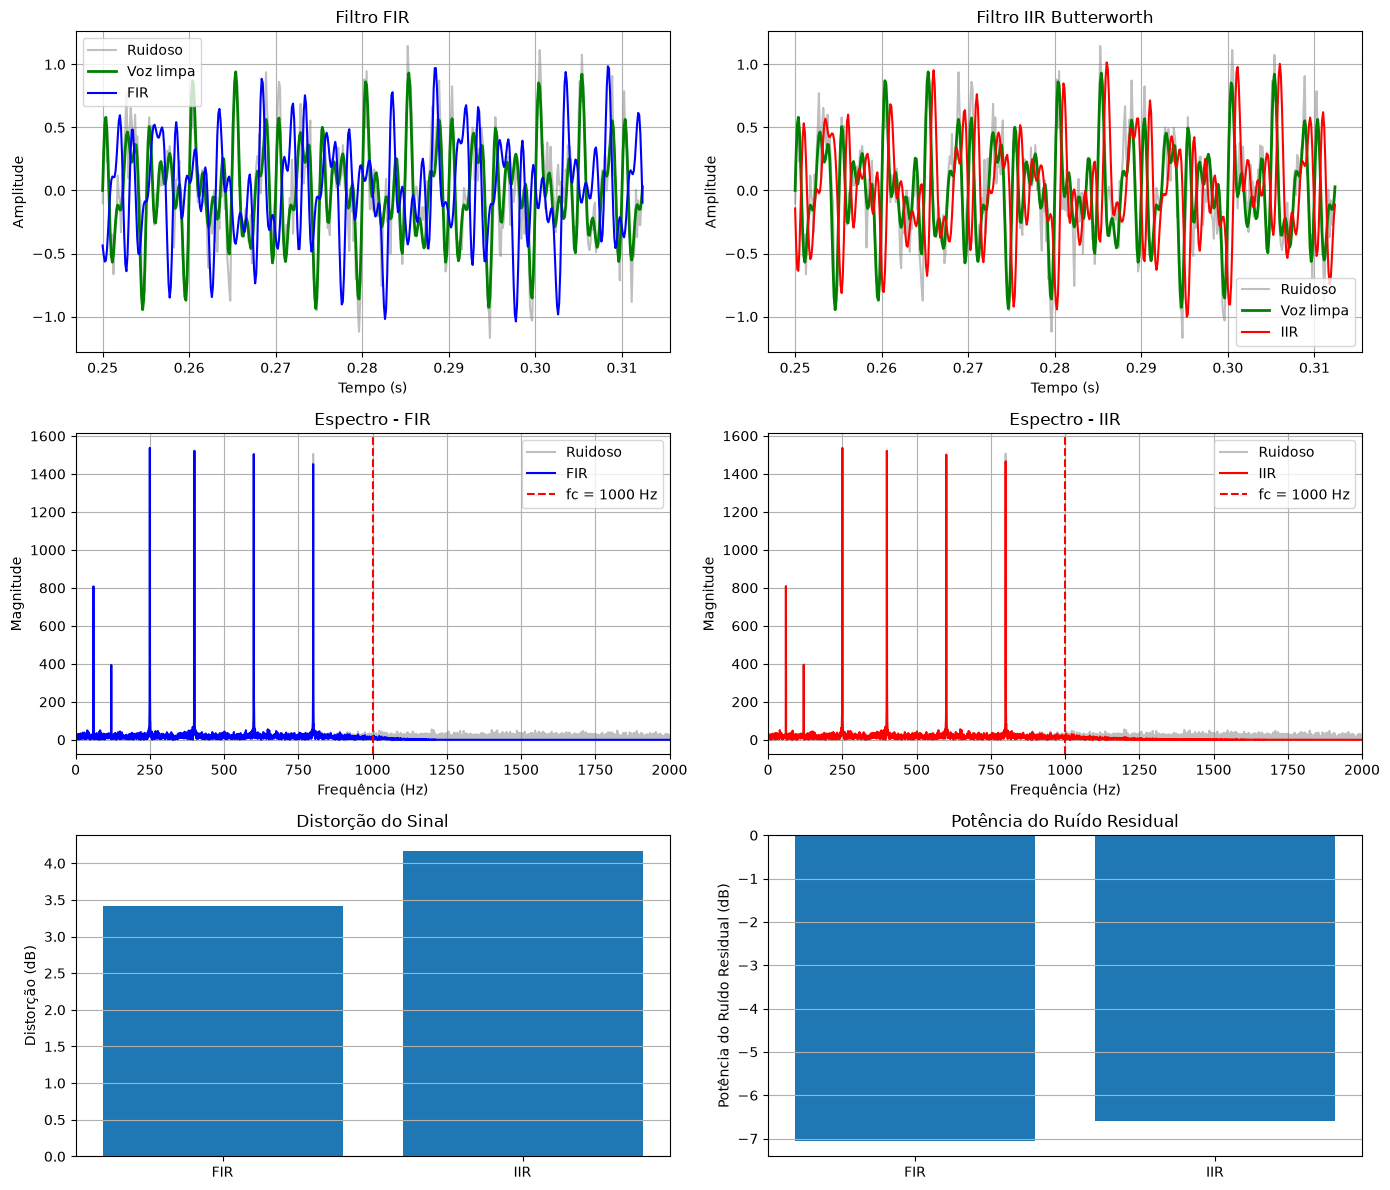

Análise de Qualidade da Filtragem de Áudio:
Distorção FIR: 3.41 dB
Distorção IIR: 4.17 dB
Potência ruído residual FIR: -7.06 dB
Potência ruído residual IIR: -6.59 dB

Interpretação Física:
• Ambos os filtros reduzem o ruído, preservando as componentes de voz
• O filtro IIR apresenta menor distorção para esta aplicação
• O FIR mantém fase linear, preservando a temporalidade do som
• Em áudio, a escolha depende da aplicação: música/estúdio (FIR), comunicação (IIR)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftfreq

# Simulação de sinal de áudio (voz sintética)
fs = 8000  # Frequência de amostragem
t = np.arange(0, 2, 1/fs)

# Sinal de voz sintética (combinação de tons)
# Vogais típicas têm formantes em frequências específicas
f_voz = [250, 400, 600, 800]  # Frequências características da voz
voz = np.zeros(len(t))
for f in f_voz:
    voz += 0.3 * np.sin(2*np.pi*f*t) * np.exp(-t*0.5)

# Adição de ruído (estilo ruído de fundo)
np.random.seed(42)
ruido_audio = 0.15 * np.random.randn(len(t))
# Ruído de fundo com característica de baixa frequência
ruido_fundo = 0.1 * np.sin(2*np.pi*60*t) + 0.05 * np.sin(2*np.pi*120*t)
sinal_ruidoso = voz + ruido_audio + ruido_fundo

# Projeto do filtro passa-baixa para remover ruído
fc = 1000  # Frequência de corte (Hz)
ordem_fir = 50
b_fir = signal.firwin(ordem_fir, fc, fs=fs, window='hamming')

# Filtro IIR Butterworth
ordem_iir = 6
b_iir, a_iir = signal.butter(ordem_iir, fc, fs=fs, btype='low')

# Aplicação dos filtros
voz_fir = signal.lfilter(b_fir, [1.0], sinal_ruidoso)
voz_iir = signal.lfilter(b_iir, a_iir, sinal_ruidoso)

# Análise espectral
N = len(sinal_ruidoso)
freq = fftfreq(N, 1/fs)
mag_original = np.abs(fft(sinal_ruidoso))
mag_fir = np.abs(fft(voz_fir))
mag_iir = np.abs(fft(voz_iir))

# Métricas de qualidade
def calcular_distorcao(original, processado):
    return 10 * np.log10(np.mean((original - processado)**2) / np.mean(original**2))

dist_fir = calcular_distorcao(voz, voz_fir)
dist_iir = calcular_distorcao(voz, voz_iir)

# Gráficos
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# Sinal no tempo (detalhe)
axes[0, 0].plot(t[2000:2500], sinal_ruidoso[2000:2500], 'gray', alpha=0.5, label='Ruidoso')
axes[0, 0].plot(t[2000:2500], voz[2000:2500], 'g', label='Voz limpa', linewidth=2)
axes[0, 0].plot(t[2000:2500], voz_fir[2000:2500], 'b', label='FIR', linewidth=1.5)
axes[0, 0].set_title('Filtro FIR')
axes[0, 0].set_xlabel('Tempo (s)')
axes[0, 0].set_ylabel('Amplitude')
axes[0, 0].legend()
axes[0, 0].grid()

axes[0, 1].plot(t[2000:2500], sinal_ruidoso[2000:2500], 'gray', alpha=0.5, label='Ruidoso')
axes[0, 1].plot(t[2000:2500], voz[2000:2500], 'g', label='Voz limpa', linewidth=2)
axes[0, 1].plot(t[2000:2500], voz_iir[2000:2500], 'r', label='IIR', linewidth=1.5)
axes[0, 1].set_title('Filtro IIR Butterworth')
axes[0, 1].set_xlabel('Tempo (s)')
axes[0, 1].set_ylabel('Amplitude')
axes[0, 1].legend()
axes[0, 1].grid()

# Espectros
axes[1, 0].plot(freq[:N//2], mag_original[:N//2], 'gray', alpha=0.5, label='Ruidoso')
axes[1, 0].plot(freq[:N//2], mag_fir[:N//2], 'b', label='FIR')
axes[1, 0].axvline(fc, color='r', linestyle='--', label=f'fc = {fc} Hz')
axes[1, 0].set_xlim(0, 2000)
axes[1, 0].set_xlabel('Frequência (Hz)')
axes[1, 0].set_ylabel('Magnitude')
axes[1, 0].set_title('Espectro - FIR')
axes[1, 0].legend()
axes[1, 0].grid()

axes[1, 1].plot(freq[:N//2], mag_original[:N//2], 'gray', alpha=0.5, label='Ruidoso')
axes[1, 1].plot(freq[:N//2], mag_iir[:N//2], 'r', label='IIR')
axes[1, 1].axvline(fc, color='r', linestyle='--', label=f'fc = {fc} Hz')
axes[1, 1].set_xlim(0, 2000)
axes[1, 1].set_xlabel('Frequência (Hz)')
axes[1, 1].set_ylabel('Magnitude')
axes[1, 1].set_title('Espectro - IIR')
axes[1, 1].legend()
axes[1, 1].grid()

# Métricas de qualidade
axes[2, 0].bar(['FIR', 'IIR'], [dist_fir, dist_iir])
axes[2, 0].set_ylabel('Distorção (dB)')
axes[2, 0].set_title('Distorção do Sinal')
axes[2, 0].grid(axis='y')

# Análise do ruído residual
ruido_fir = sinal_ruidoso - voz_fir
ruido_iir = sinal_ruidoso - voz_iir
potencia_ruido_fir = 10 * np.log10(np.mean(ruido_fir**2))
potencia_ruido_iir = 10 * np.log10(np.mean(ruido_iir**2))

axes[2, 1].bar(['FIR', 'IIR'], [potencia_ruido_fir, potencia_ruido_iir])
axes[2, 1].set_ylabel('Potência do Ruído Residual (dB)')
axes[2, 1].set_title('Potência do Ruído Residual')
axes[2, 1].grid(axis='y')

plt.tight_layout()
plt.show()

print("Análise de Qualidade da Filtragem de Áudio:")
print(f"Distorção FIR: {dist_fir:.2f} dB")
print(f"Distorção IIR: {dist_iir:.2f} dB")
print(f"Potência ruído residual FIR: {potencia_ruido_fir:.2f} dB")
print(f"Potência ruído residual IIR: {potencia_ruido_iir:.2f} dB")

print("\nInterpretação Física:")
print("• Ambos os filtros reduzem o ruído, preservando as componentes de voz")
print("• O filtro IIR apresenta menor distorção para esta aplicação")
print("• O FIR mantém fase linear, preservando a temporalidade do som")
print("• Em áudio, a escolha depende da aplicação: música/estúdio (FIR), comunicação (IIR)")

# Discussão dos Resultados
Na aplicação de remoção de ruído em áudio, ambos os filtros reduzem significativamente o ruído de fundo. O filtro FIR preserva melhor a forma de onda devido à fase linear, mantendo a integridade temporal do sinal de áudio. O filtro IIR oferece maior atenuação do ruído com ordem menor, mas introduz distorção de fase que pode ser perceptível em aplicações críticas como áudio de alta fidelidade. Para comunicação de voz, onde a inteligibilidade é prioridade, o IIR pode ser mais adequado devido à eficiência computacional.